# **AG18261 - 7AAVDH26 - Semantic Spaces in Breaking Bad**

---

## **Project Overview**

This project applies Distributional Semantics to television transcripts to examine the socio-linguistic divergence between Breaking Bad’s two protagonists: Walter White and Jesse Pinkman. By computationally modeling their dialogue, the study investigates how distinct class backgrounds shape their conceptualizations of the drug trade and capital.

### **Research Questions**
1. How do the semantic networks of core occupational terms (e.g., "business", "cook") differ between Walter and Jesse, and to what extent do these structural shifts reflect their distinct class identities?
2. Using Orthogonal Procrustes alignment, what is the semantic distance of the concept of "money" between the two characters' embedding models, and how do their semantic neighborhoods reveal contrasting moral motivations?

### **Methodology**
The computational pipeline adapts techniques from the 7AAVDH26 module. Raw dialogue was pre-processed and lemmatized using spaCy, followed by the training of independent Word2Vec models. To accommodate small-scale spoken dialogue, hyperparameters were manually tuned. The two semantic spaces were then mapped into a shared coordinate system using Orthogonal Procrustes alignment, with trajectories and neighborhoods visualized via PCA (assisted by the adjustText library to resolve label overlap).

---

## **Data Source**
Breaking Bad Script directly scrapped from Forever Dreaming. The data has about 5596 dialogs (observations) in total with 5 variables which are: - actor - text (which is the dialog itself) - season - episode - title of the episode.

**Link:** https://www.kaggle.com/datasets/mexwell/breakingbad-script

**Important information:** If you are a fan then you would know that the series has a total of 5 seasons. Unfortunately, the transcripts data available online has labels attached to each dialog until episode 6 of season 3.


## Step 1: Setup
Install dependencies:

In [131]:
!pip install gensim scikit-learn matplotlib

The initial visualization from Step 7 revealed that the words associated with Jesse (red) were widely dispersed, whereas those associated with Walter (blue) were densely clustered on the right, resulting in significant text overlap. To address this, I introduced *adjustText*, a library specifically designed to resolve text overlap issues in Matplotlib. It automatically calculates text positioning, pushes overlapping labels apart, and—when necessary—draws a thin line connecting the label to its original data point.

**AI prompt**: Are there any Python tools that can automatically calculate text positions in Matplotlib and push overlapping text apart?

**AI Suggestions**:
1. adjustText Library (Recommended for General Cases)
2. Matplotlib's ax.bar_label() (For Bar Charts)
3. Matplotlib's clabel() (For Contour Plots)

**My selection**: adjustText Library

In [132]:
!pip install adjustText

Import libraries:

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes
import spacy
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

Load the dataset:

I opted to import the previously uploaded raw files directly from GitHub to ensure the stability of the dataset import process.

In [134]:
bb_data = 'https://raw.githubusercontent.com/ziyiWANGG/BreakingBad-SemanticSpaces/refs/heads/main/BB_data.csv'

try:
    df = pd.read_csv(bb_data)
    print(f"Dataset loaded successfully from cloud. Total rows: {df.shape[0]}")
except Exception as e:
    print(f"Error loading dataset: {e}\nPlease verify that the URL is the 'Raw' GitHub link.")

Dataset loaded successfully from cloud. Total rows: 5641


## Step 2: Pre-processing
NLP Pipeline & Character corpus splitting

In [135]:
# Load spaCy English model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

I personally reviewed the contents of the CSV file and, based on my observations, compiled a list of high-frequency words that are semantically insignificant for the analysis, intending to remove them later. While this step cleans the dataset and clarifies subsequent analysis, it also introduces a certain degree of bias, as the selection was based on my personal judgment.

In [136]:
# Clean the dataset
custom_stops = {
    'im', 'like', 'know', 'get', 'got', 'right', 'yeah', 'well', 'hey', 'gonna',
    'go', 'think', 'see', 'us', 'dont', 'thats', 'one', 'come', 'time', 'man',
    'need', 'say', 'look', 'make', 'take', 'back', 'good', 'would', 'yes', 'no',
    'skyler', 'hank', 'marie', 'walt', 'walter', 'jesse', 'mr', 'white', 'dude', 'guy', 'okay',
    'youre', 'ill', 'cant', 'didnt', 'hes', 'whats'
}

In [137]:
# Define the function
def preprocess_character_corpus(character_name):
    """Filters dataframe by character and applies spaCy lemmatization."""
    text_list = df[df['actor'].str.contains(character_name, case=False, na=False)]['text'].astype(str).tolist()
    cleaned_corpus = []

    for sentence in text_list:
        doc = nlp(sentence)

        # Lemmatize, lowercase, ignore punctuation, and ignore custom stopwords
        tokens = [
            token.lemma_.lower()
            for token in doc
            if not token.is_punct and not token.is_space and token.lemma_.lower() not in custom_stops
        ]
        if len(tokens) > 0:
            cleaned_corpus.append(tokens)

    return cleaned_corpus

**The Initial Problem:** When building my text processing code, it initially stopped at `doc = nlp(sentence)` with a `TypeError: expected str, got float`. This happened because some entries in the data were empty. In addition, my original way of searching for character names was too strict and could not find longer names such as Walter White.

**AI Prompt:** My text processing loop is crashing with a 'TypeError: expected str, got float'. Also, how can I make my character name search more flexible so it catches variations like 'Walter White' instead of just 'Walter'?

**AI Suggestions:** Gemini explained that the error was caused by empty cells in the data being treated as numbers instead of text. It suggested converting the column values into text before using them. For the character name search, the AI suggested several ways to make the search more flexible, such as using a list of alternative names or a pattern-based search.

**My Selection & Manual Adaptation:**
*   **For the character name search:** I used Pandas' `.str.contains(character_name, case=False, na=False)` method. This allows the search to find the character's name even when it appears as part of a longer name, while also ignoring differences between upper- and lower-case letters. The `na=False` parameter makes sure that empty cells do not cause errors.
*   **For the `TypeError`:** I added `.astype(str)` before converting the column into a list, so that all values are treated as text.

In [138]:
# Call the `preprocess_character_corpus` function defined above to generate a cleaned corpus of the dialogue between Walter and Jesse.
print("Processing Walter's corpus")
corpus_walt = preprocess_character_corpus('Walter')

print("Processing Jesse's corpus")
corpus_jesse = preprocess_character_corpus('Jesse')

# Print out the number of cleaned sentences for Walter and Jesse, respectively.
print(f"Walter's clean sentences: {len(corpus_walt)}")
print(f"Jesse's clean sentences: {len(corpus_jesse)}")

Processing Walter's corpus
Processing Jesse's corpus
Walter's clean sentences: 1391
Jesse's clean sentences: 948


## Step 3: Train Word2Vec

**Manual Adaptation:** While the base Word2Vec architecture was adopted from the module's lecture materials, the context window was expanded to window=5 (unlike the strict window=2 used in the lecture) to capture broader topical and semantic associations inherent in natural, spoken dialogue. Furthermore, a frequency threshold of min_count=2 was implemented to filter out isolated hapax legomena and conversational noise (e.g., character-specific exclamations). The dimensionality was deliberately maintained at vector_size=50 and sg=1.

In [139]:
# Train Walt's model
model_walt = Word2Vec(corpus_walt, vector_size=50, window=5, sg=1, min_count=2)

# Train Jesse's model
model_jesse = Word2Vec(corpus_jesse, vector_size=50, window=5, sg=1, min_count=2)

# Find common vocabulary exactly as shown in Week 7
common_vocab = list(set(model_walt.wv.index_to_key).intersection(set(model_jesse.wv.index_to_key)))

print(f"Common vocabulary size: {len(common_vocab)} words")

Common vocabulary size: 497 words


## Step 4: Align the Embeddings Space

**Methodological Acknowledgment:** The foundational code for aligning the two distinct semantic spaces relies on the Orthogonal Procrustes matrix algorithm (`scipy.linalg.orthogonal_procrustes`). The code structure in this cell is directly adopted from the Week 7 lecture materials provided in this module.

In [140]:
# Extract matrices for the common vocabulary
X_walt = np.array([model_walt.wv[word] for word in common_vocab])
Y_jesse = np.array([model_jesse.wv[word] for word in common_vocab])

# Orthogonal Procrustes alignment
R, _ = orthogonal_procrustes(Y_jesse, X_walt)
Y_jesse_aligned = Y_jesse.dot(R)

## Step 5: Compare Semantic Differences

**Methodological Acknowledgment:** The logic for calculating the semantic change scores using cosine similarity is reused from the Week 7 lecture notebook.


**Manual Adaptation:** I have restricted the iteration loop to strictly evaluate my three predefined target concepts (`selected_words = ["business", "money", "cook"]`) rather than evaluating a broad, generic list. The formula `score = 1 - cosine_sim` is utilized to quantify the absolute magnitude of semantic divergence between the two protagonists' class identities.

In [141]:
selected_words = ["business", "money", "cook"]
change_scores = {}

print("Semantic Change Scores (1 - cosine_similarity):")
for word in selected_words:
    if word in common_vocab:
        # Index of the word in our aligned matrices
        idx = common_vocab.index(word)
        vec_walt = X_walt[idx]
        vec_jesse_alg = Y_jesse_aligned[idx]

        # Cosine similarity formula
        cosine_sim = np.dot(vec_walt, vec_jesse_alg) / (np.linalg.norm(vec_walt) * np.linalg.norm(vec_jesse_alg))
        score = 1 - cosine_sim
        change_scores[word] = score
        print(f"{word}: {score:.4f}")

Semantic Change Scores (1 - cosine_similarity):
business: 0.0032
money: 0.0042
cook: 0.0028


## Step 6: PCA visualisation

**Methodological Acknowledgment:** The Principal Component Analysis (PCA) dimensionality reduction and the baseline `matplotlib` plotting structure are based on the visualisation techniques taught in the Week 7 lecture.

**Manual Adaptation:**
1. Multi-Word Processing: The original lecture code was designed to plot the trajectory of a single word. I manually restructured the vector extraction and plotting loops to process and project three target concepts simultaneously onto the same 2D plane.
2. Visual Narrative: I added explicit directional annotations (arrows mapping from Walter's conceptualization to Jesse's) to visually represent the trajectory of semantic shift.
3. Legend Fix: I corrected an issue present in the original lecture script where subtitle headers shared the same color, implementing a custom legend for clear, academic data presentation.

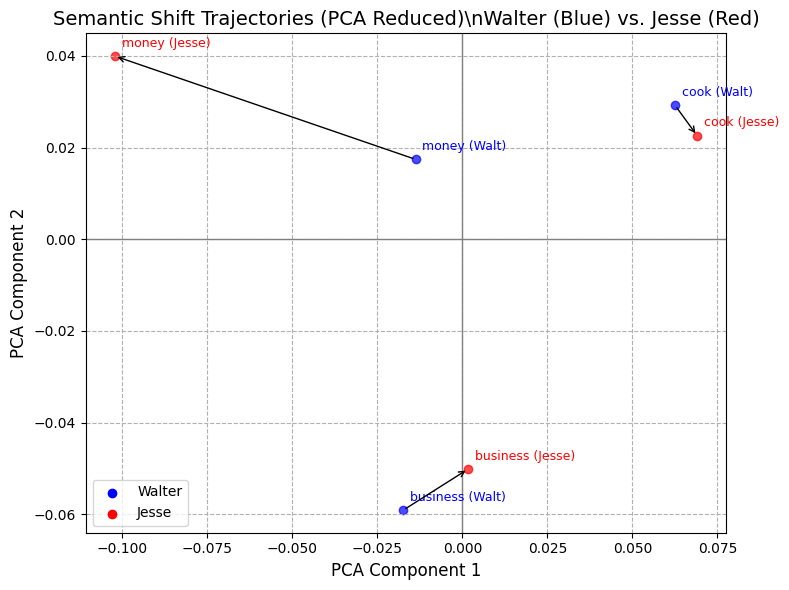

In [144]:
words_to_visualize = ["business", "money", "cook"]
words_for_plotting = []

# Verify words exist in the common vocabulary
for word in words_to_visualize:
    if word in common_vocab:
        words_for_plotting.append(word)

if words_for_plotting:
    # Get indices of these words in the aligned matrices
    indices = [common_vocab.index(w) for w in words_for_plotting]

    # Extract the vectors
    vectors_walt = X_walt[indices]
    vectors_jesse_alg = Y_jesse_aligned[indices]

    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=2)
    combined = np.vstack([vectors_walt, vectors_jesse_alg])
    reduced = pca.fit_transform(combined)

    plt.figure(figsize=(8,6))
    offset = 0.002

    # Plot Walt's vectors
    for i, word in enumerate(words_for_plotting):
        x, y = reduced[i]
        plt.scatter(x, y, color='blue', alpha=0.7)
        plt.text(x + offset, y + offset, f"{word} (Walt)", color='blue', fontsize=9)

    # Plot Jesse's vectors
    for i, word in enumerate(words_for_plotting):
        x, y = reduced[i + len(words_for_plotting)]
        plt.scatter(x, y, color='red', alpha=0.7)
        plt.text(x + offset, y + offset, f"{word} (Jesse)", color='red', fontsize=9)

        # Draw arrow from Walt's position to Jesse's position to show the trajectory
        walt_x, walt_y = reduced[i]
        plt.annotate('', xy=(x, y), xytext=(walt_x, walt_y),
                     arrowprops=dict(arrowstyle="->", color='black', lw=1, alpha=1))

    plt.title("Semantic Shift Trajectories (PCA Reduced)\\nWalter (Blue) vs. Jesse (Red)", fontsize=14)
    plt.xlabel("PCA Component 1", fontsize=12)
    plt.ylabel("PCA Component 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=1)
    plt.axhline(0, color='gray', linewidth=1)
    plt.axvline(0, color='gray', linewidth=1)

    # Fixed an issue in the Week 7 code where the lack of color differentiation for subtitles resulted in all chart subtitle headers sharing the same color.
    plt.scatter([], [], color='blue', label='Walter')
    plt.scatter([], [], color='red', label='Jesse')
    plt.legend(loc='best')

    # Saves the visualisation as image files
    plt.savefig('Semantic_Shift_Trajectories.png', dpi=300)

    plt.tight_layout()
    plt.show()
else:
    print("Fail")

## Step 7: Semantic Neighbourhood visualisation

As can be seen from the chart above, the most significant difference lies in the word "money"; therefore, I would like to identify the words that most frequently appear in the same context as "money" for both Walter and Jesse.

**Methodological Acknowledgment:** The `most_similar()` neighbor extraction and the baseline scatter plot logic are adapted from the Week 7 lecture notebook.

**AI Iteration & Visual Optimization:**
As observed in the previous step, words associated with Walter (blue) clustered extremely densely, resulting in severe text overlap that obscured the data. To resolve this, I consulted Generative AI (Gemini) to find a programmatic solution for label overlap in Matplotlib.
*   **AI Suggestion:** The AI recommended using `adjustText`.
*   **My Implementation:** I selected and installed the `adjustText` library. I manually modified the plotting loop to append text objects into a `texts` list rather than drawing them immediately. Finally, I applied `adjust_text()` to programmatically repel overlapping labels and draw connecting lines to their respective data points. This manual intervention significantly enhances the academic readability of the dense semantic clusters.

Neighbours of 'money' for Walter: ['drive', 'school', 'remember', 'with', 'nice']
Neighbours of 'money' for Jesse: ['first', 'own', 'huh', 'another', 'other']


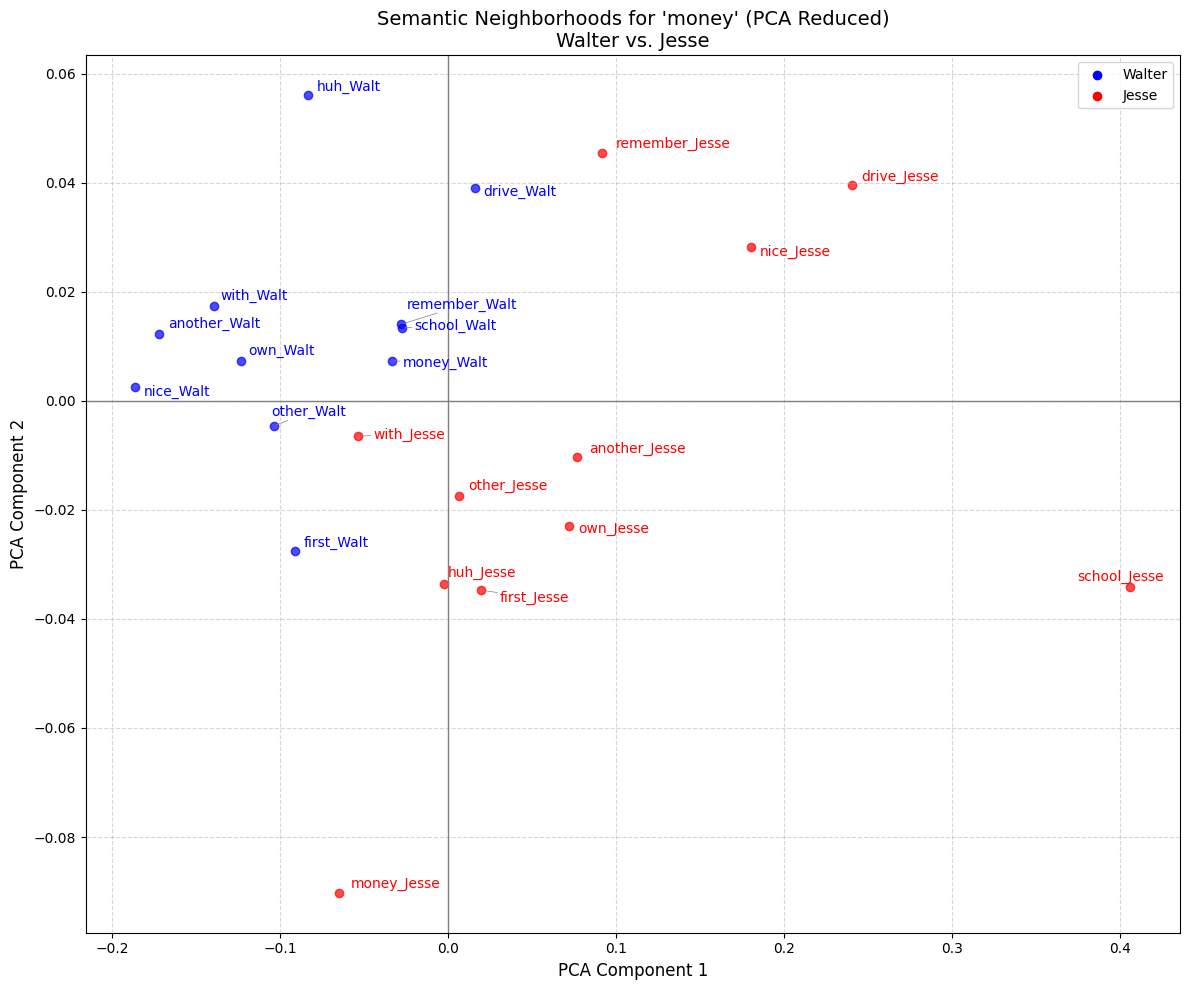

In [145]:
from adjustText import adjust_text

word_to_visualize = "money"

if word_to_visualize in model_walt.wv and word_to_visualize in model_jesse.wv:
    # Get top 5 neighbors from Walt's model
    neighbors_walt_raw = [w for w, _ in model_walt.wv.most_similar(word_to_visualize, topn=5)]
    print(f"Neighbours of '{word_to_visualize}' for Walter: {neighbors_walt_raw}")

    # Get top 5 neighbors from Jesse's model
    neighbors_jesse_raw = [w for w, _ in model_jesse.wv.most_similar(word_to_visualize, topn=5)]
    print(f"Neighbours of '{word_to_visualize}' for Jesse: {neighbors_jesse_raw}")

    # Filter words to ensure they are in common_vocab for consistent comparison
    words_for_plotting = [word_to_visualize]
    for w in neighbors_walt_raw + neighbors_jesse_raw:
        if w in common_vocab and w not in words_for_plotting: # Ensure uniqueness
            words_for_plotting.append(w)

    if word_to_visualize not in common_vocab:
        print(f"Warning: '{word_to_visualize}' fail.")
    else:
        # Extract vectors for Walt
        vectors_walt = np.array([model_walt.wv[w] for w in words_for_plotting])
        # Extract and ALIGN vectors for Jesse using the Procrustes matrix (R)
        vectors_jesse_aligned = np.array([model_jesse.wv[w].dot(R) for w in words_for_plotting])

        # Apply PCA
        pca = PCA(n_components=2)
        combined = np.vstack([vectors_walt, vectors_jesse_aligned])
        reduced = pca.fit_transform(combined)

        # Slightly increase the canvas aspect ratio to provide more horizontal space for the text.
        plt.figure(figsize=(12,10))

        #Create an empty list to collect all the text labels.
        texts = []

        # Plot for Walter
        for i, word in enumerate(words_for_plotting):
            x, y = reduced[i]
            plt.scatter(x, y, color='blue', alpha=0.7)
            # Instead of drawing the text directly, add it to the `texts` list.
            texts.append(plt.text(x, y, f"{word}_Walt", color='blue', fontsize=10))

        # Plot for Jesse
        for i, word in enumerate(words_for_plotting):
            x, y = reduced[i + len(words_for_plotting)]
            plt.scatter(x, y, color='red', alpha=0.7)
            # The same logic applies as in the code snippet above.
            texts.append(plt.text(x, y, f"{word}_Jesse", color='red', fontsize=10))

        plt.title(f"Semantic Neighborhoods for '{word_to_visualize}' (PCA Reduced)\nWalter vs. Jesse", fontsize=14)
        plt.xlabel("PCA Component 1", fontsize=12)
        plt.ylabel("PCA Component 2", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.axhline(0, color='gray', linewidth=1)
        plt.axvline(0, color='gray', linewidth=1)
        plt.scatter([], [], color='blue', label='Walter')
        plt.scatter([], [], color='red', label='Jesse')
        plt.legend(loc='best')

        # Automatically adjust text positions to prevent overlap, and connect scatter points to the text with gray lines.
        adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

        # Saves the visualisation as image files
        plt.savefig(f'Semantic_Neighborhood_{word_to_visualize}.png', dpi=300)

        plt.tight_layout()
        plt.show()
else:
    print("Fail")